# Preprocessing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
import sys
from concurrent.futures import ThreadPoolExecutor


### Load data from each plane

In [3]:
plane2 = np.genfromtxt("data/plane2.csv", delimiter=",")
plane3 = np.genfromtxt("data/plane3.csv", delimiter=",")
plane4 = np.genfromtxt("data/plane4.csv", delimiter=",")
plane5 = np.genfromtxt("data/plane5.csv", delimiter=",")
plane6 = np.genfromtxt("data/plane6.csv", delimiter=",")
allplanes = [plane2, plane3, plane4, plane5, plane6]

[  5.21560352   6.09997621  13.02125436 ...  34.0496583  -12.15346486
  17.27890364]


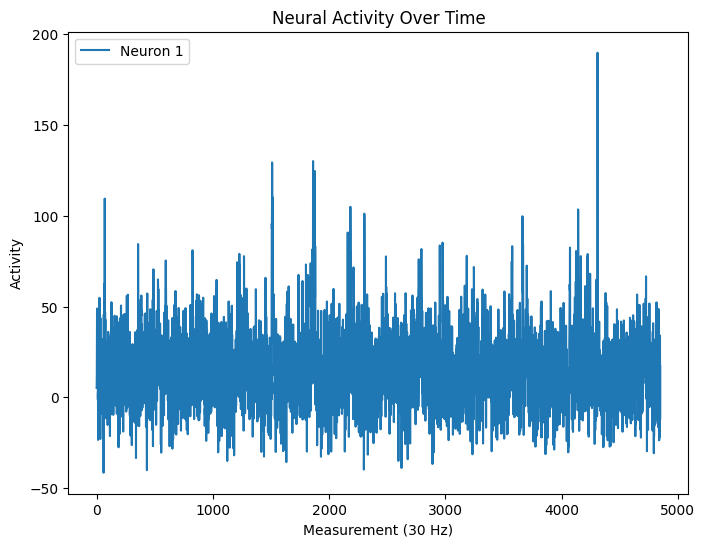

In [4]:
# Neuronal activity for neuron 1
print(plane2[0])

# Plot data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, plane2.shape[1]), plane2[0,:], label="Neuron 1")
plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

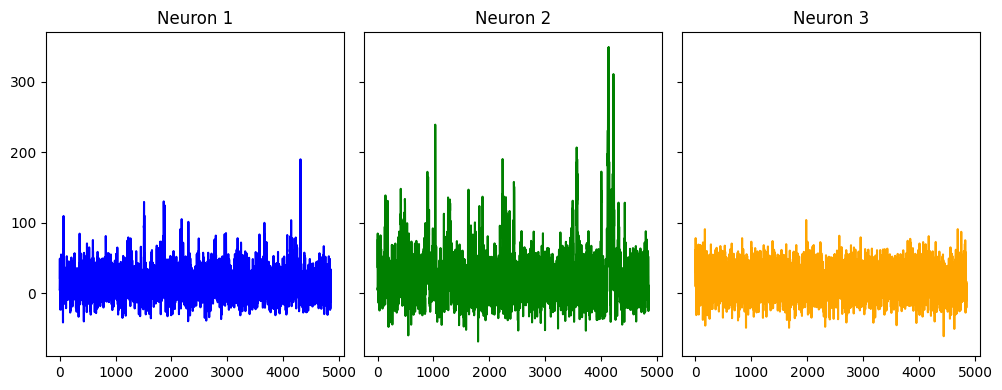

In [5]:
# Plot of 3 neurons
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
ax1.plot(np.arange(0, plane2.shape[1]), plane2[0,:], label="Neuron 1", color='blue')
ax2.plot(np.arange(0, plane2.shape[1]), plane2[1,:], label="Neuron 2", color='green')
ax3.plot(np.arange(0, plane2.shape[1]), plane2[2,:], label="Neuron 3", color='orange')
ax1.set_title("Neuron 1")
ax2.set_title("Neuron 2")
ax3.set_title("Neuron 3")
plt.tight_layout()
plt.show()

# 1 Relative change normalization (deltaF/F0)

In [6]:
window_size = 300

# Normalize one full plane and return the result
def normalize_plane(plane, plane_index, window_size):
    n_neurons, n_frames = plane.shape
    norm_data = np.zeros_like(plane, dtype=float)

    for j in range(n_neurons):
        neuron = plane[j]
        for t in range(n_frames):
            start = max(0, t - window_size)
            if t == 0:
                F0 = neuron[0]
            else:
                window = neuron[start:t]
                if window.size <= 1:
                    F0 = neuron[0]
                else:
                    median = np.percentile(window, 50)
                    lower_half = window[window < median]
                    F0 = np.mean(lower_half)
            if F0 == 0:
                F0 = 1e-6
            norm_data[j, t] = (neuron[t] - F0) / F0

    return plane_index, norm_data

# Parallel process the planes and save the normalized data
plane_args = [(plane, i, window_size) for i, plane in enumerate(allplanes)]
with ThreadPoolExecutor() as executor:
    plane_results = list(executor.map(lambda args: normalize_plane(*args), plane_args))

for plane_index, norm_data in sorted(plane_results, key=lambda x: x[0]):
    np.savetxt(f"data/norm_plane{plane_index+2}.csv", norm_data, delimiter=",")
    print(f"Plane {plane_index+2} normalized")


Plane 2 normalized
Plane 3 normalized
Plane 4 normalized
Plane 5 normalized
Plane 6 normalized


In [7]:
# Read norm_data from csv
plane2_norm = np.genfromtxt("data/norm_plane2.csv", delimiter=",")
plane3_norm = np.genfromtxt("data/norm_plane3.csv", delimiter=",")
plane4_norm = np.genfromtxt("data/norm_plane4.csv", delimiter=",")
plane5_norm = np.genfromtxt("data/norm_plane5.csv", delimiter=",")
plane6_norm = np.genfromtxt("data/norm_plane6.csv", delimiter=",")

allplanes_norm = [plane2_norm, plane3_norm, plane4_norm, plane5_norm, plane6_norm]

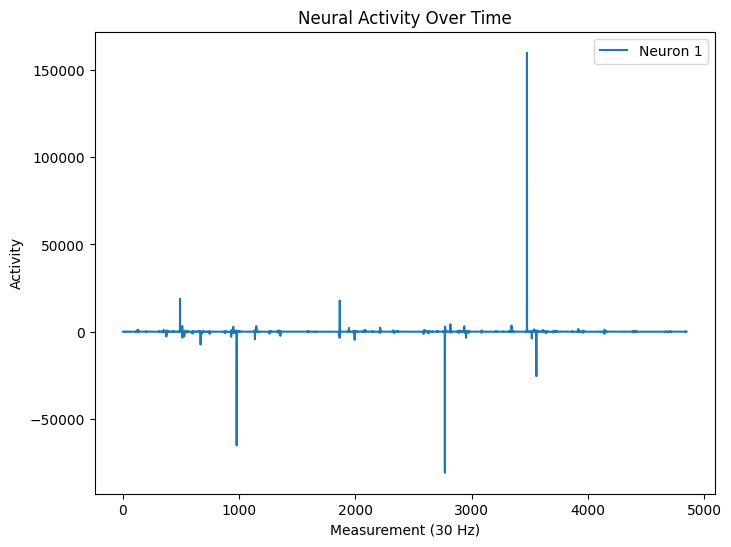

In [8]:
# Plot normalized data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(plane2_norm[0,:], label="Neuron 1")
plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

# 2 Pearson correlation

### 2.1 Correlation matrix summary (plot and stats)

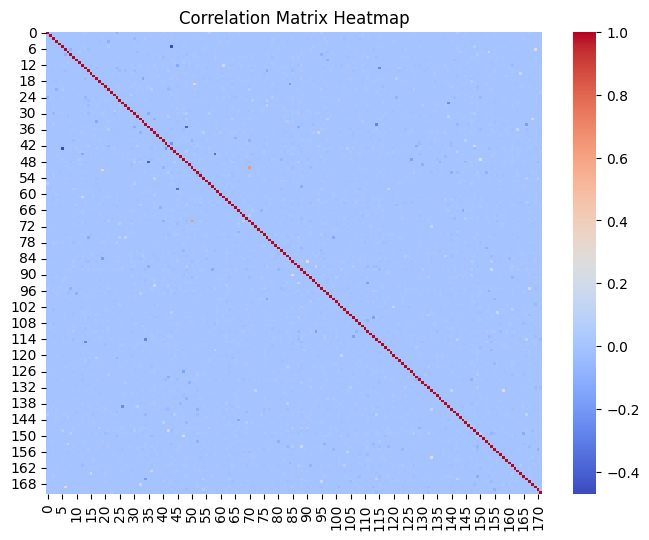

[[ 1.00000000e+00 -1.31250755e-03 -9.41155259e-04 ... -9.42220444e-04
   6.55226590e-05  5.80925275e-04]
 [-1.31250755e-03  1.00000000e+00  3.88887914e-04 ... -1.71118413e-03
  -4.26907746e-04  3.38550624e-04]
 [-9.41155259e-04  3.88887914e-04  1.00000000e+00 ...  1.30982685e-03
  -1.15812659e-03 -8.80405401e-04]
 ...
 [-9.42220444e-04 -1.71118413e-03  1.30982685e-03 ...  1.00000000e+00
   1.44538349e-02  5.24778280e-03]
 [ 6.55226590e-05 -4.26907746e-04 -1.15812659e-03 ...  1.44538349e-02
   1.00000000e+00  2.15036492e-04]
 [ 5.80925275e-04  3.38550624e-04 -8.80405401e-04 ...  5.24778280e-03
   2.15036492e-04  1.00000000e+00]]
[1.72267608e-06 8.85773222e-07 3.46630130e-07 ... 2.08913343e-04
 2.75392243e-05 4.62406930e-08]
                R^2
count  1.470600e+04
mean   2.112717e-04
std    4.791564e-03
min    2.379795e-15
25%    1.416074e-07
50%    1.006625e-06
75%    7.295223e-06
max    4.177884e-01


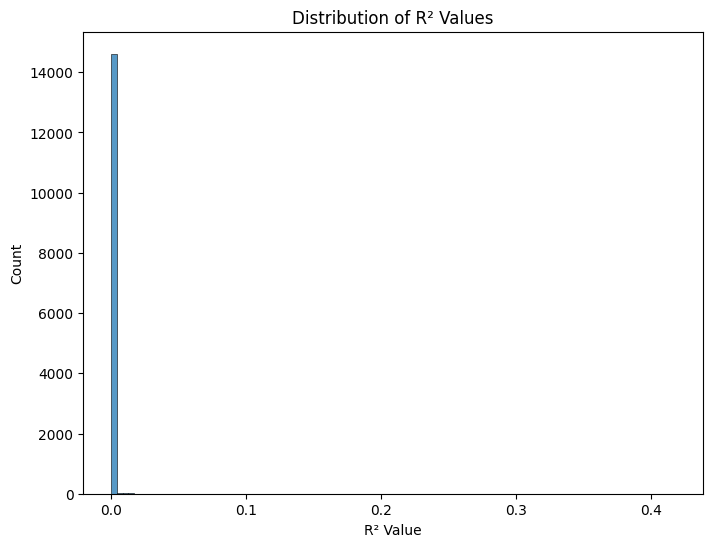

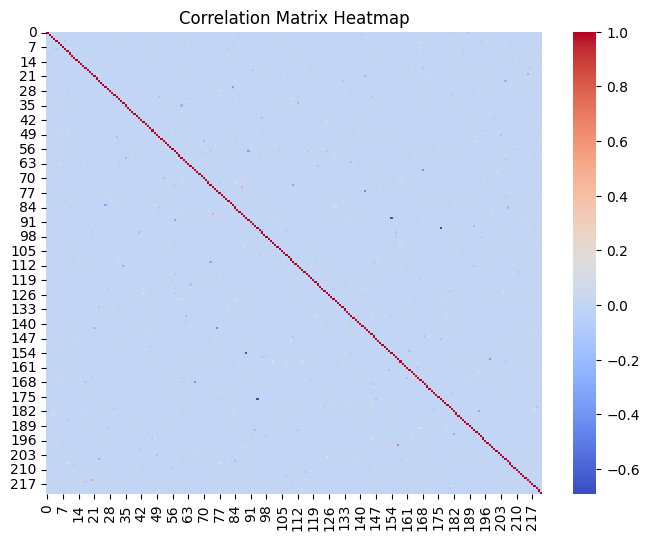

[[ 1.00000000e+00  2.23344707e-03 -1.66282494e-03 ...  1.34015165e-03
   8.50728073e-04 -2.41185633e-05]
 [ 2.23344707e-03  1.00000000e+00  4.84710632e-02 ...  2.46699260e-03
  -6.89200096e-04  4.04856685e-04]
 [-1.66282494e-03  4.84710632e-02  1.00000000e+00 ... -2.27691563e-03
  -4.03847893e-04 -7.95876819e-03]
 ...
 [ 1.34015165e-03  2.46699260e-03 -2.27691563e-03 ...  1.00000000e+00
  -9.68241721e-04  8.87736260e-05]
 [ 8.50728073e-04 -6.89200096e-04 -4.03847893e-04 ... -9.68241721e-04
   1.00000000e+00  3.61491663e-03]
 [-2.41185633e-05  4.04856685e-04 -7.95876819e-03 ...  8.87736260e-05
   3.61491663e-03  1.00000000e+00]]
[4.98828579e-06 2.76498680e-06 4.31479475e-07 ... 9.37492030e-07
 7.88075668e-09 1.30676222e-05]
                R^2
count  2.453100e+04
mean   2.461932e-04
std    6.115670e-03
min    6.651203e-16
25%    1.710331e-07
50%    1.154521e-06
75%    8.065862e-06
max    4.771932e-01


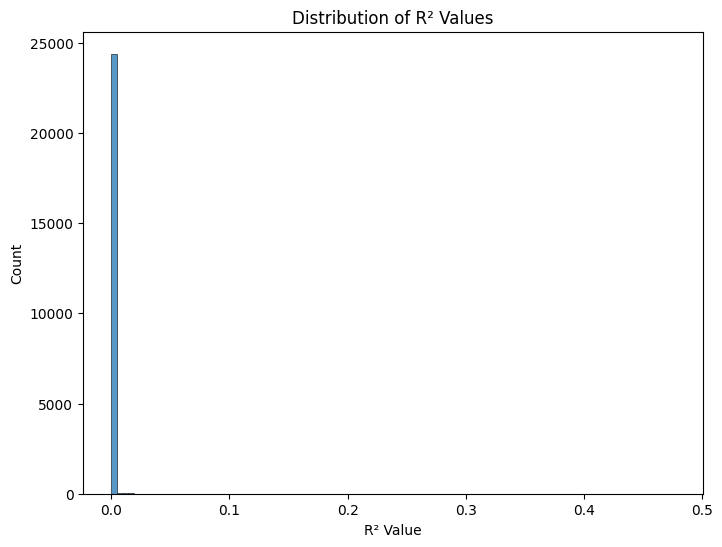

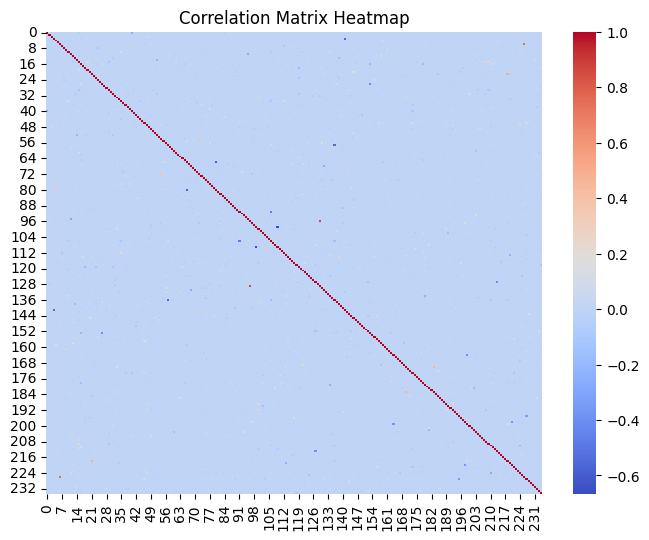

[[ 1.00000000e+00  1.99389804e-04  4.19568412e-06 ... -5.37410647e-04
  -8.42302443e-05 -1.55316133e-03]
 [ 1.99389804e-04  1.00000000e+00  1.50812907e-04 ...  6.87847190e-04
  -9.86816701e-04 -1.42750846e-03]
 [ 4.19568412e-06  1.50812907e-04  1.00000000e+00 ...  9.47196035e-04
   2.44507906e-03 -1.04336888e-03]
 ...
 [-5.37410647e-04  6.87847190e-04  9.47196035e-04 ...  1.00000000e+00
  -1.81185688e-03 -6.33440463e-04]
 [-8.42302443e-05 -9.86816701e-04  2.44507906e-03 ... -1.81185688e-03
   1.00000000e+00  2.95064970e-04]
 [-1.55316133e-03 -1.42750846e-03 -1.04336888e-03 ... -6.33440463e-04
   2.95064970e-04  1.00000000e+00]]
[3.97562938e-08 1.76037653e-11 8.88800807e-07 ... 3.28282534e-06
 4.01246820e-07 8.70633365e-08]
                R^2
count  2.749500e+04
mean   2.993983e-04
std    8.024290e-03
min    4.101707e-15
25%    1.139908e-07
50%    8.501923e-07
75%    6.235407e-06
max    7.446331e-01


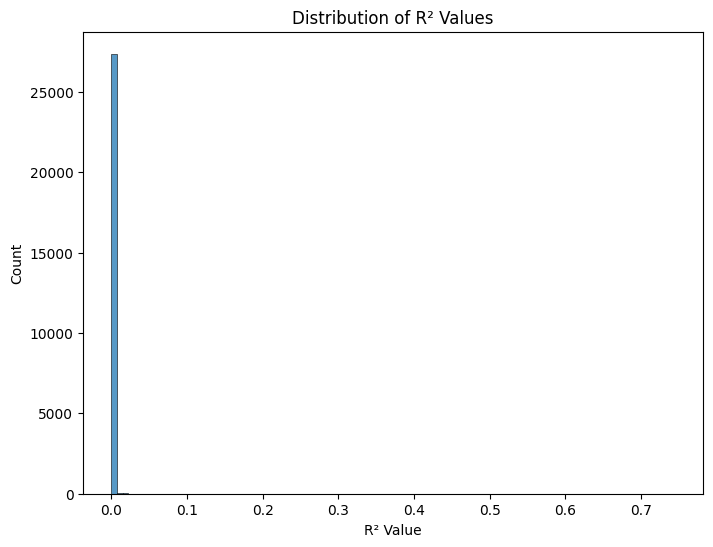

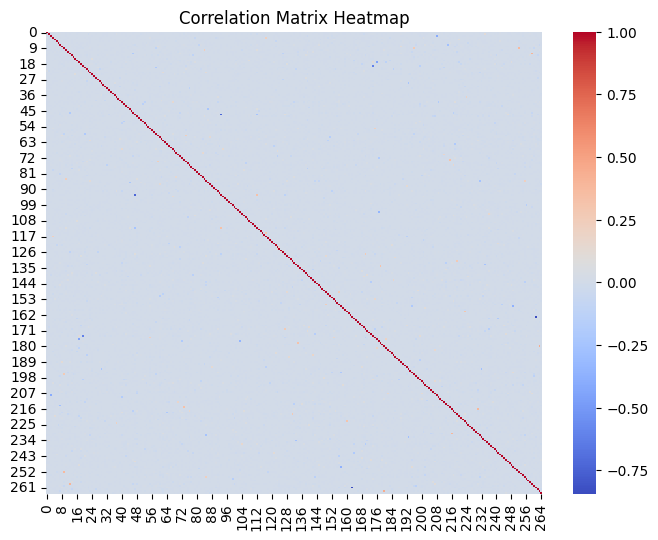

[[ 1.00000000e+00 -4.42395678e-03 -4.21513389e-04 ... -2.75884750e-04
  -6.60698203e-05  4.30646138e-04]
 [-4.42395678e-03  1.00000000e+00 -1.08236834e-02 ...  1.08164446e-03
  -1.46512179e-04 -7.98086082e-04]
 [-4.21513389e-04 -1.08236834e-02  1.00000000e+00 ...  1.67234918e-04
  -7.20093936e-04  8.96975791e-04]
 ...
 [-2.75884750e-04  1.08164446e-03  1.67234918e-04 ...  1.00000000e+00
  -1.46339852e-03 -2.72519294e-02]
 [-6.60698203e-05 -1.46512179e-04 -7.20093936e-04 ... -1.46339852e-03
   1.00000000e+00 -3.85687346e-03]
 [ 4.30646138e-04 -7.98086082e-04  8.96975791e-04 ... -2.72519294e-02
  -3.85687346e-03  1.00000000e+00]]
[1.95713936e-05 1.77673537e-07 4.63371857e-04 ... 2.14153522e-06
 7.42667656e-04 1.48754729e-05]
                R^2
count  3.498000e+04
mean   2.211499e-04
std    6.109597e-03
min    5.981456e-16
25%    1.493785e-07
50%    1.041634e-06
75%    7.130034e-06
max    7.111047e-01


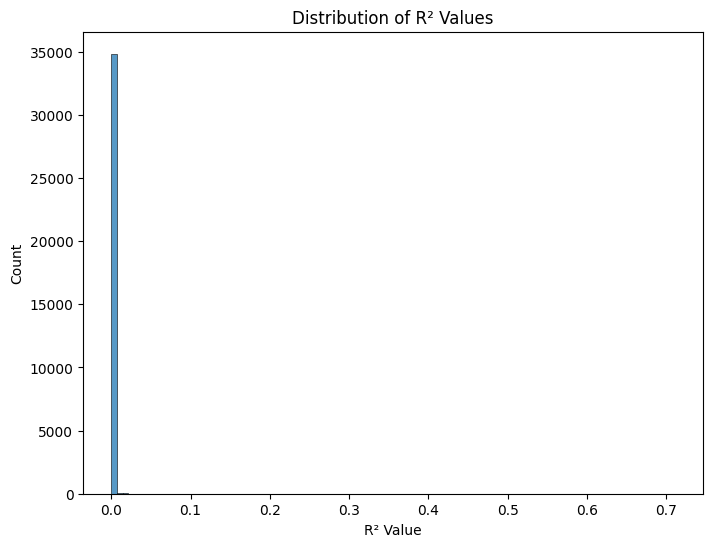

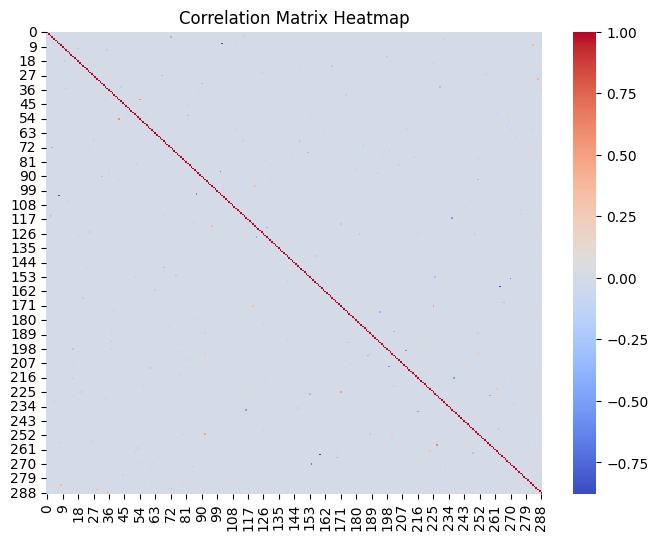

[[ 1.00000000e+00  2.72081604e-03 -1.00058105e-03 ... -1.25365080e-04
   1.19073535e-04  4.38958040e-04]
 [ 2.72081604e-03  1.00000000e+00  1.50633263e-03 ... -3.79228707e-02
   1.49772916e-04 -6.03808776e-04]
 [-1.00058105e-03  1.50633263e-03  1.00000000e+00 ... -5.36398020e-04
   4.43298043e-03 -1.97354960e-04]
 ...
 [-1.25365080e-04 -3.79228707e-02 -5.36398020e-04 ...  1.00000000e+00
   4.39743474e-03  4.08029587e-04]
 [ 1.19073535e-04  1.49772916e-04  4.43298043e-03 ...  4.39743474e-03
   1.00000000e+00 -3.12765742e-04]
 [ 4.38958040e-04 -6.03808776e-04 -1.97354960e-04 ...  4.08029587e-04
  -3.12765742e-04  1.00000000e+00]]
[7.40283990e-06 1.00116243e-06 1.70350571e-07 ... 1.93374323e-05
 1.66488144e-07 9.78224093e-08]
                R^2
count  4.161600e+04
mean   2.687930e-04
std    7.638908e-03
min    5.235375e-15
25%    1.345591e-07
50%    9.588288e-07
75%    6.860270e-06
max    7.692439e-01


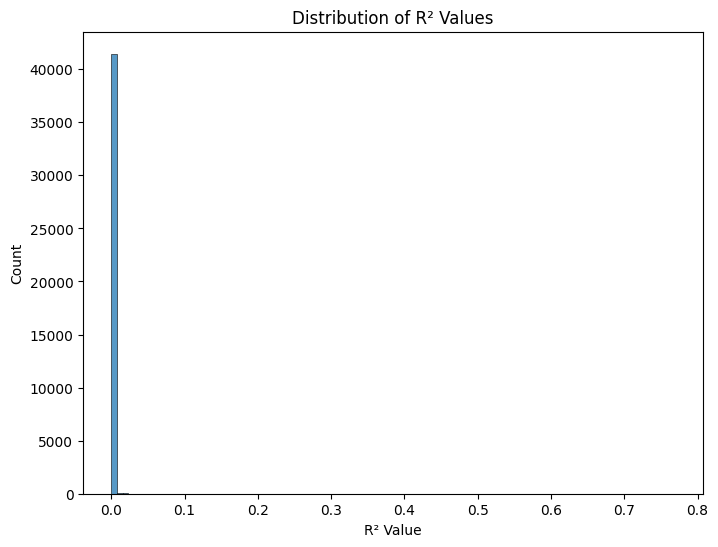

In [9]:
for i in range(len(allplanes_norm)):
    plane = allplanes_norm[i]
    corr_matrix = np.corrcoef(plane)

    # Plot correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, cmap='coolwarm')
    plt.title('Correlation Matrix Heatmap')
    plt.show()

    # Summary stats for r^2 values
    corr_matrix = np.corrcoef(plane)
    print(corr_matrix)
    r2_vals = np.square(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
    print(r2_vals)
    df = pd.DataFrame(r2_vals, columns=['R^2'])
    print(df.describe())

    # Plot histogram of r^2 values
    plt.figure(figsize=(8, 6))
    sns.histplot(r2_vals, bins=100)
    plt.xlabel('R² Value')
    plt.title('Distribution of R² Values')
    plt.show()

### 2.2 Thresholded correlation matrix

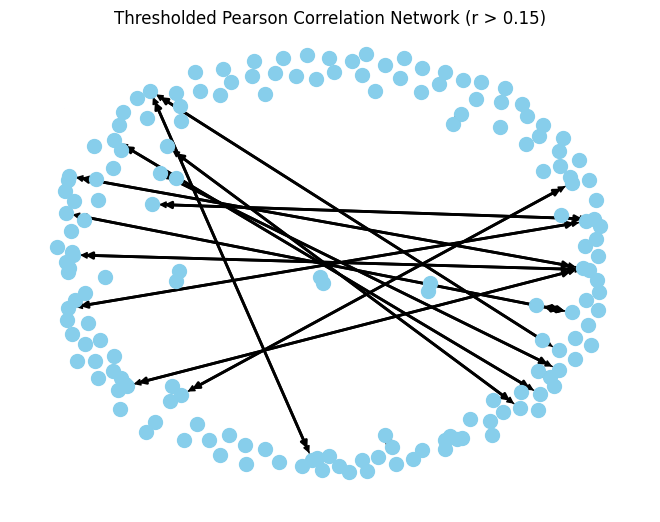

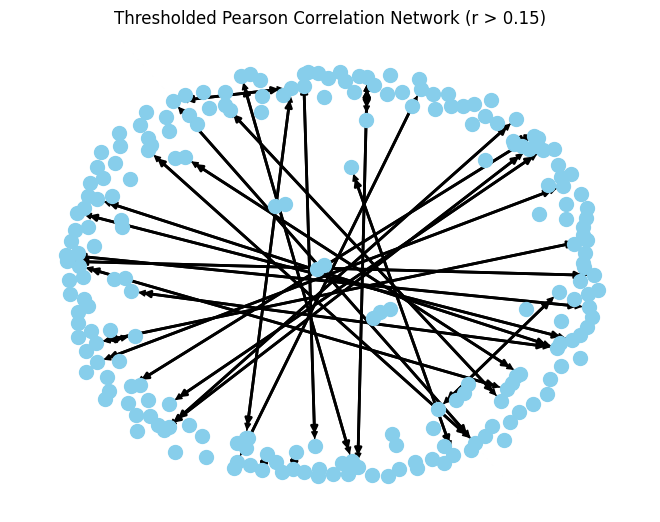

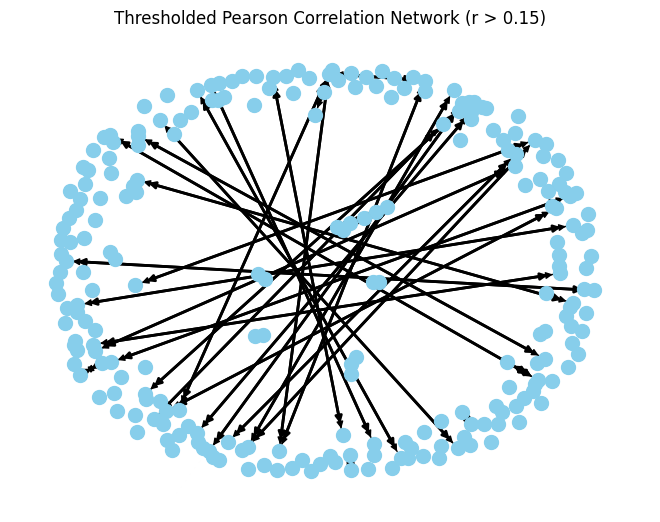

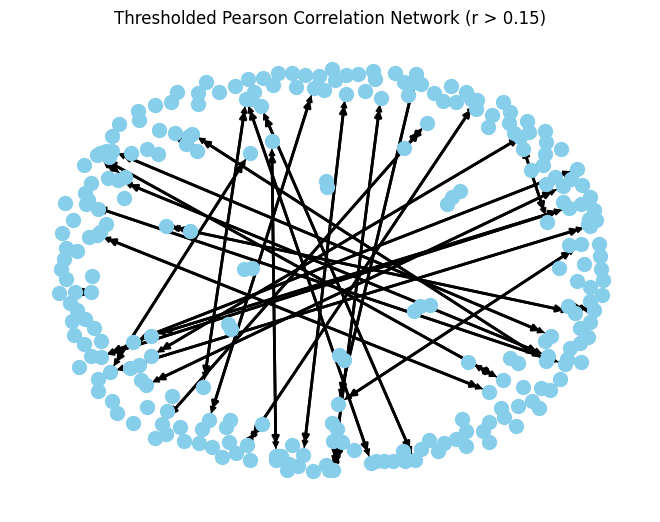

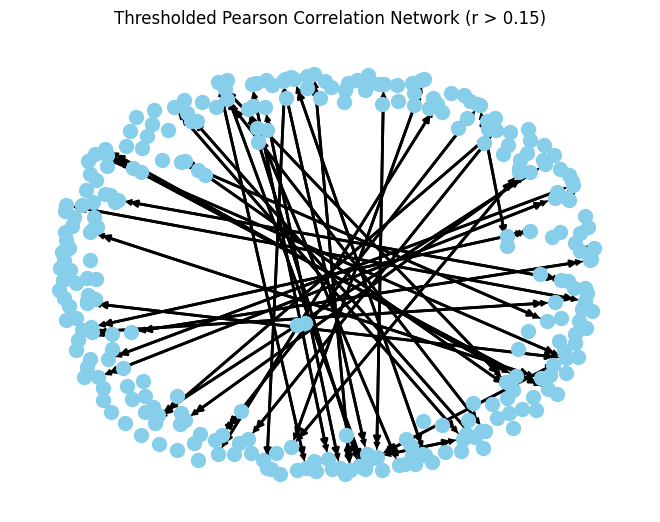

In [26]:
for i in range(len(allplanes_norm)):
    plane = allplanes_norm[i]
    corr_matrix = np.corrcoef(plane)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)

    # Threshold weak correlations
    threshold = 0.15
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

    pos = nx.spring_layout(G, seed=42)

    nx.draw(G, pos, node_color='skyblue', node_size=100)

    nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

    plt.title(f"Thresholded Pearson Correlation Network (r > {threshold:.2f})")
    plt.show()

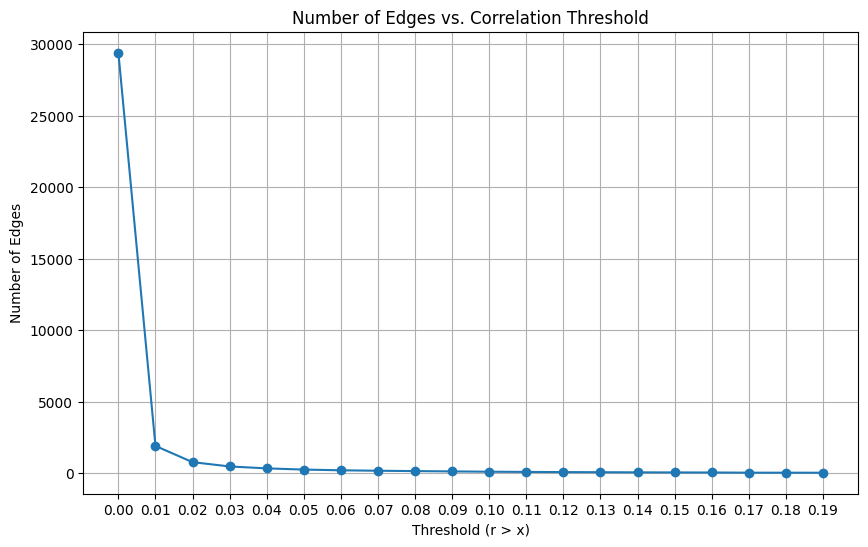

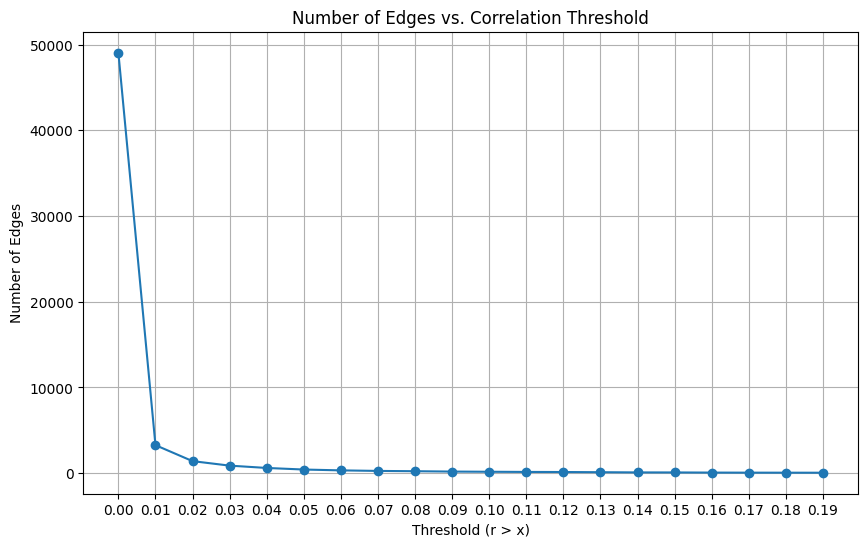

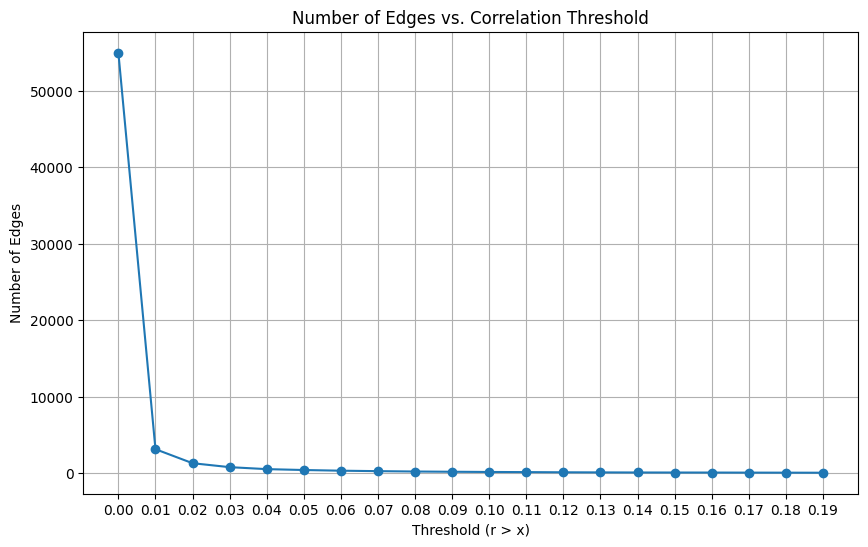

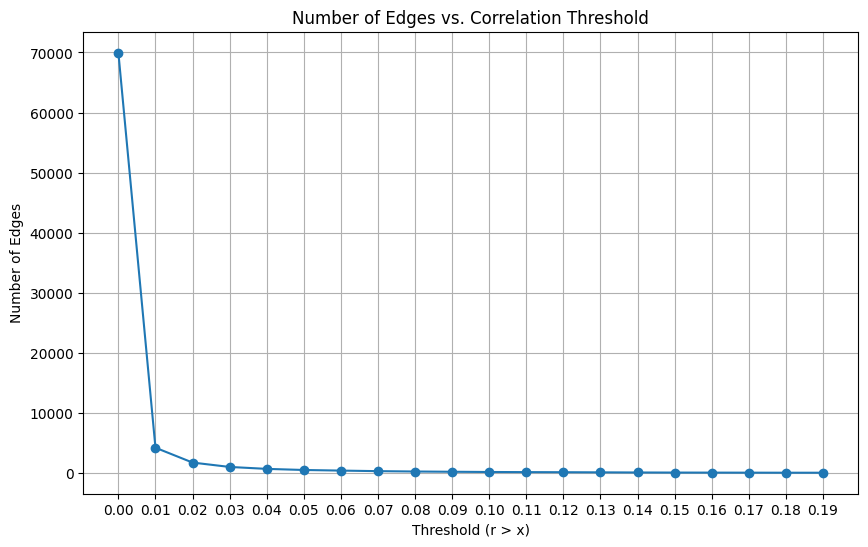

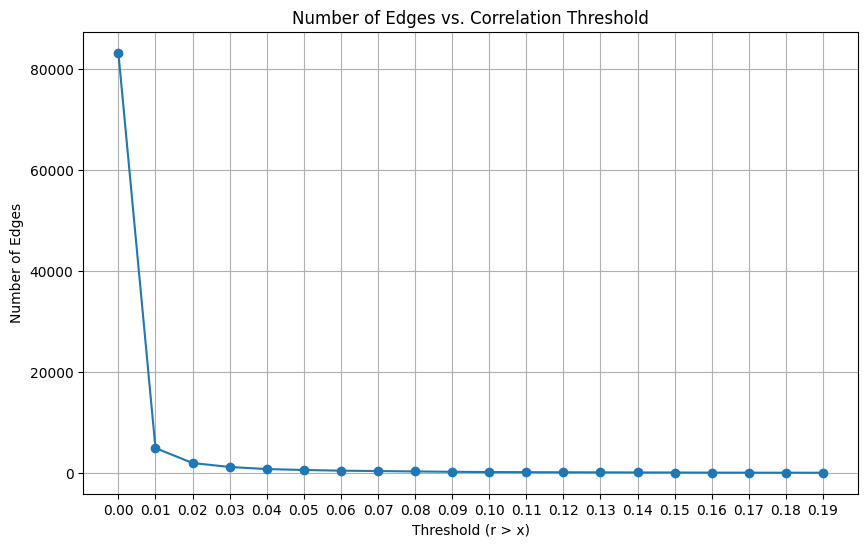

In [25]:
# Analyze correlation matrix with different thresholds
for plane_num, plane in enumerate(allplanes_norm):
    norm_data = plane
    num_edges = []
    for i in range(0, 20):
        corr_matrix = np.corrcoef(norm_data)

        # Remove self-correlations
        np.fill_diagonal(corr_matrix, 0)

        # Threshold weak correlations
        threshold = 0.01 * i
        corr_matrix[np.abs(corr_matrix) < threshold] = 0

        # Create undirected weighted graph
        G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)
        pos = nx.spring_layout(G, seed=42)

        num_edges.append(G.number_of_edges())
            
        # print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")
        nx.write_graphml(G,f"plane{plane_num+2}_neurons{threshold*100:.0f}.graphml")

    # Plot number of edges vs. threshold
    plt.figure(figsize=(10, 6))
    plt.plot([0.01 * i for i in range(0, 20)], num_edges, marker='o')
    plt.xlabel('Threshold (r > x)')
    plt.ylabel('Number of Edges')
    plt.title('Number of Edges vs. Correlation Threshold')
    plt.xticks([0.01 * i for i in range(0, 20)])
    plt.grid()
    plt.show()

# Sensitivity Analysis

In [ ]:
def compute_modularity(partition, A):
    """
    Compute modularity Q for a given partition.
    Q = (1/2m) * sum_ij (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    where k_i is the degree of node i, and delta(c_i, c_j) = 1 if nodes i,j in same community
    """
    n = A.shape[0]

    degrees = A.sum(axis=1)
    m = A.sum() / 2.0  # total edges (double counted in adjacency matrix)
    
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    
    Q /= (2.0 * m)
    return Q

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
            
    penalty = (singleton_count/(len(partition)))+(double_count/(len(partition)*2))
    return (np.mean(conductances) + (1-np.mean(conductances))*penalty) if conductances else np.nan

def communities_to_partition(communities, G_undirected):
    """
    Convert a list of community sets to a partition array.
    Returns: array where partition[i] = community_id for node i
    """
    node_list = list(G_undirected.nodes())  # Use the current graph's node order
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    partition = np.zeros(len(node_list), dtype=int)
    for community_id, community_set in enumerate(communities):
        for node in community_set:
            partition[node_to_idx[node]] = community_id
    return partition

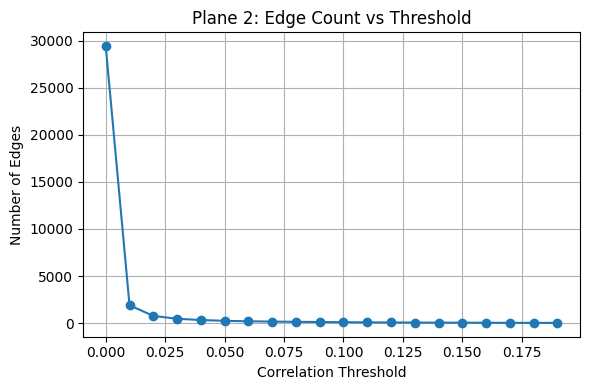

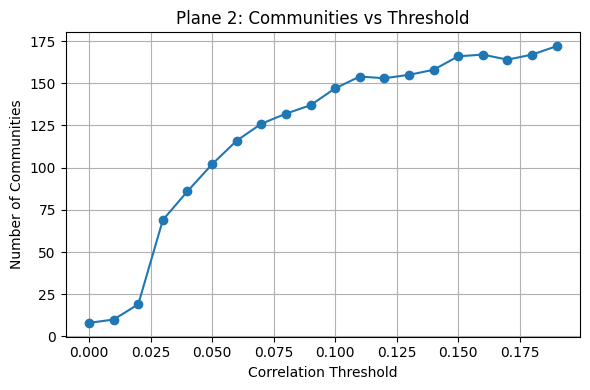

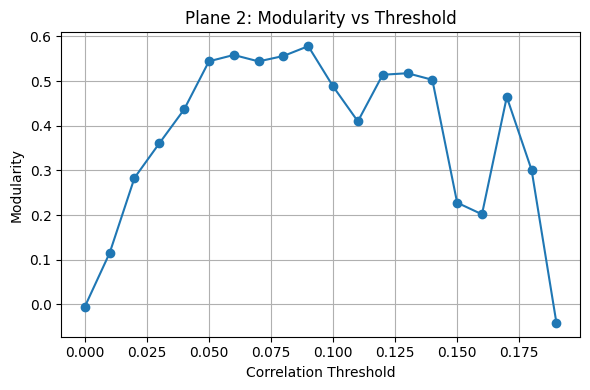

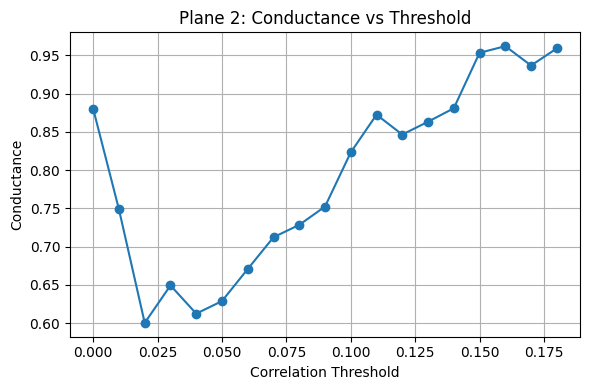

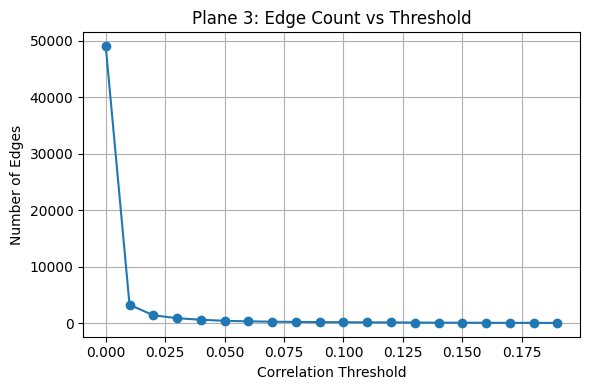

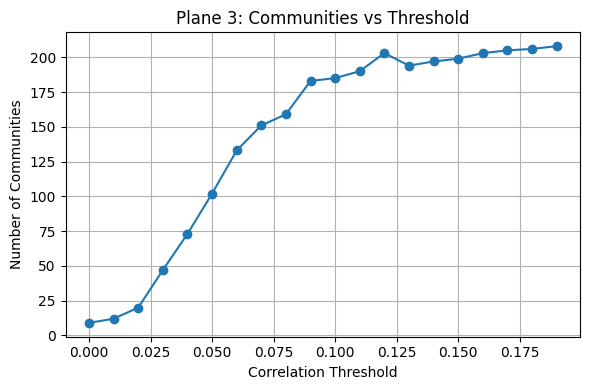

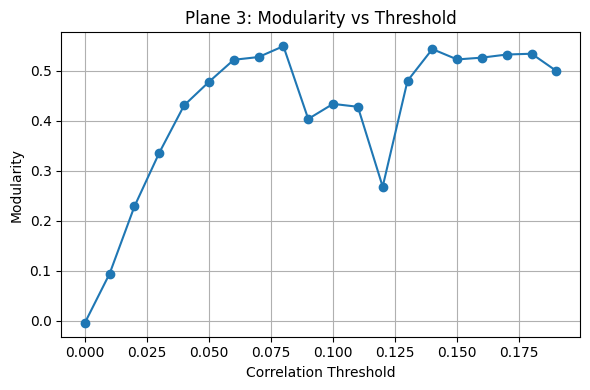

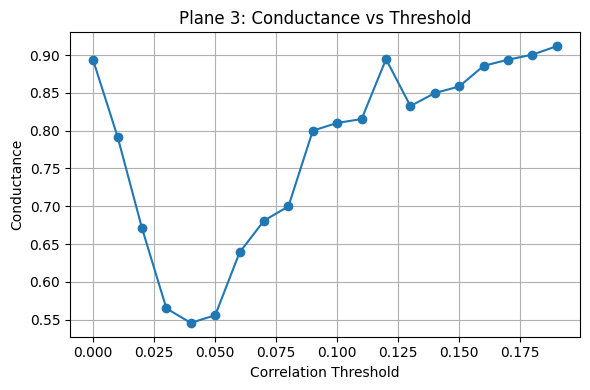

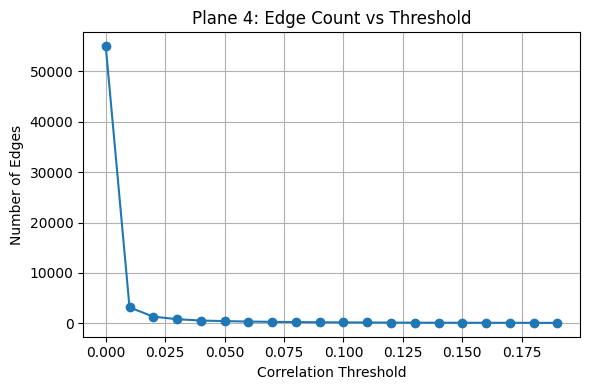

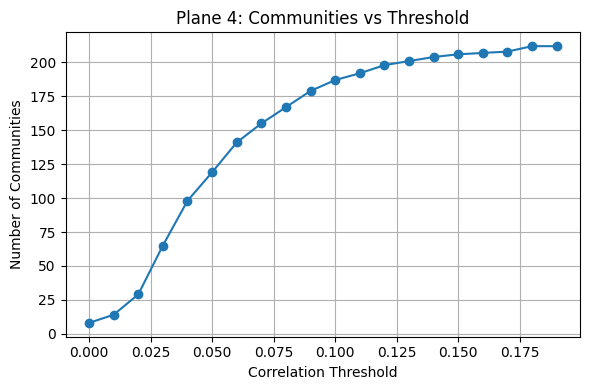

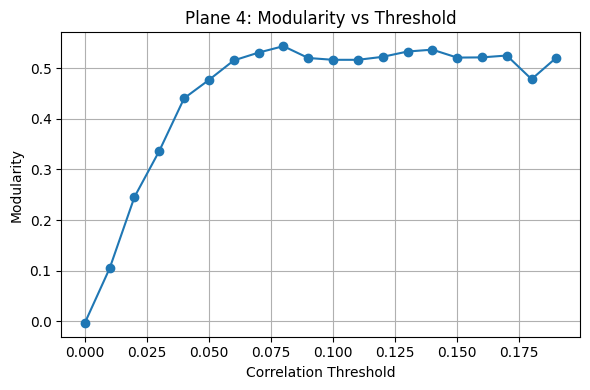

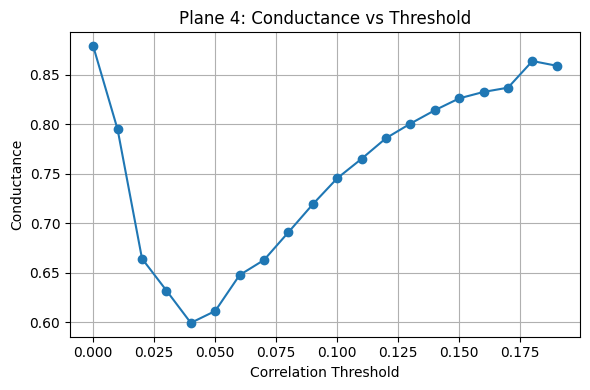

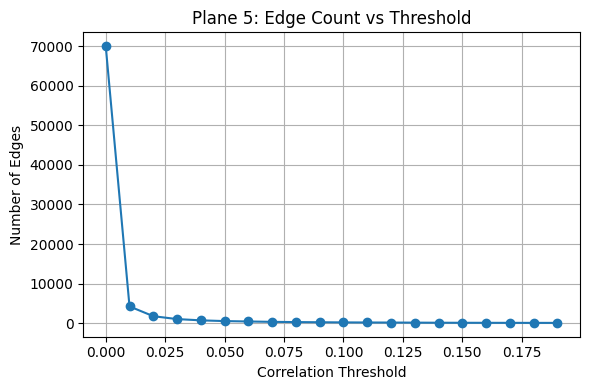

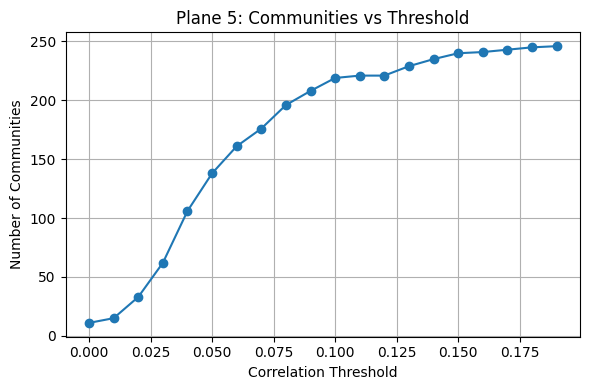

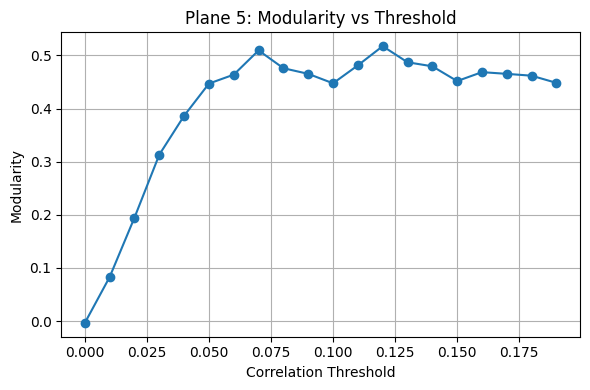

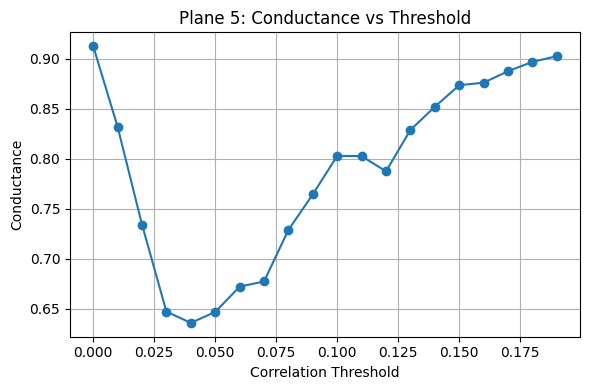

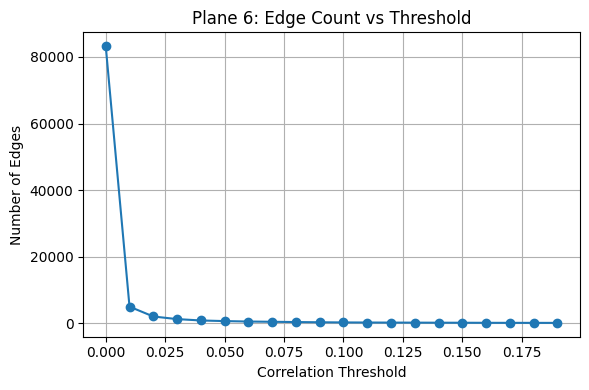

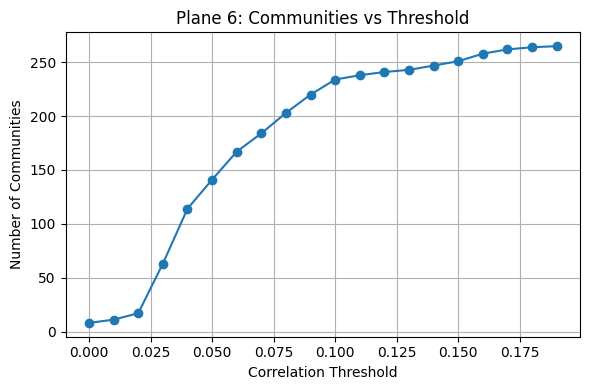

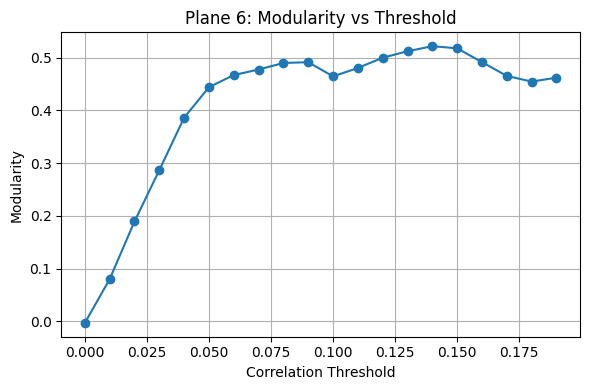

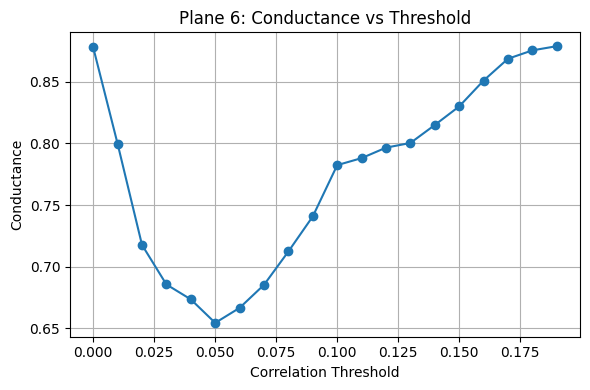

In [23]:
for x in range(len(allplanes_norm)):
    plane = allplanes_norm[x]
    corr_matrix = np.corrcoef(plane)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)
    
    sensitivity_results = []

    # loop through thresholds
    for i in range(0,20):
        threshold = 0.01 * i
        
        # make a thresholded copy
        corr_matrix[np.abs(corr_matrix) < threshold] = 0

        # Create undirected weighted graph
        G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)
        # Convert directed graph to undirected
        G_undirected = G.to_undirected()

        # Remove any remaining self-loops
        G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

        # Create unweighted adjacency matrix
        A = nx.adjacency_matrix(G_undirected, weight=None).toarray()
        
        # compute parameters
        communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42))
        partition_louvain = communities_to_partition(communities_louvain, G_undirected)
        mod = compute_modularity(partition_louvain, A)
        cond = compute_conductance(partition_louvain, A)
        k = len(communities_louvain)
        
        # append to results array
        sensitivity_results.append({
        'threshold'  : round(threshold, 3),
        'n_edges'    : G.number_of_edges(),
        'k'          : k,
        'modularity' : round(mod,  4),
        'conductance': round(cond, 4),
        })
        
    df = pd.DataFrame(sensitivity_results)
    
    
    # number of edges
    plt.figure(figsize=(6,4))
    plt.plot(df["threshold"], df["n_edges"], marker='o')
    plt.xlabel("Correlation Threshold")
    plt.ylabel("Number of Edges")
    plt.title(f"Plane {x+2}: Edge Count vs Threshold")
    plt.grid(True)
    plt.tight_layout()
    
    # number of communities
    plt.figure(figsize=(6,4))
    plt.plot(df["threshold"], df["k"], marker='o')
    plt.xlabel("Correlation Threshold")
    plt.ylabel("Number of Communities")
    plt.title(f"Plane {x+2}: Communities vs Threshold")
    plt.grid(True)
    plt.tight_layout()
    
    # modularity
    plt.figure(figsize=(6,4))
    plt.plot(df["threshold"], df["modularity"], marker='o')
    plt.xlabel("Correlation Threshold")
    plt.ylabel("Modularity")
    plt.title(f"Plane {x+2}: Modularity vs Threshold")
    plt.grid(True)
    plt.tight_layout()
    
    # conductance
    plt.figure(figsize=(6,4))
    plt.plot(df["threshold"], df["conductance"], marker='o')
    plt.xlabel("Correlation Threshold")
    plt.ylabel("Conductance")
    plt.title(f"Plane {x+2}: Conductance vs Threshold")
    plt.grid(True)
    plt.tight_layout()

    plt.show()